In [4]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import os
import cv2
from tqdm import tqdm

# Base project path (CHANGE if needed)
BASE_PATH = r"D:\College\Major project\Dataset"

# Raw dataset paths
ANTI_SPOOF = os.path.join(BASE_PATH, "Anti-Spoofing Dataset, 30,000 sets")
FFPP = os.path.join(BASE_PATH, "FaceForensics++_C23")

# Output folders
OUTPUT_REAL = os.path.join(BASE_PATH, "dataset_final", "real")
OUTPUT_SPOOF = os.path.join(BASE_PATH, "dataset_final", "spoof")

os.makedirs(OUTPUT_REAL, exist_ok=True)
os.makedirs(OUTPUT_SPOOF, exist_ok=True)

print("Paths configured successfully.")

Paths configured successfully.


In [3]:
def process_videos(input_folder, output_folder):
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith((".mp4", ".avi", ".mov")):

                video_path = os.path.join(root, file)
                cap = cv2.VideoCapture(video_path)

                frame_count = 0
                saved_count = 0
                video_name = os.path.splitext(file)[0]

                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break

                    if frame_count % FRAME_SKIP == 0:
                        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

                        filename = f"{video_name}_{saved_count}.jpg"
                        save_path = os.path.join(output_folder, filename)

                        cv2.imwrite(save_path, frame)
                        saved_count += 1

                    frame_count += 1

                cap.release()

    print(f"✅ Done processing: {input_folder}")


In [4]:
def process_images(input_folder, output_folder):
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):

                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                save_path = os.path.join(output_folder, file)

                cv2.imwrite(save_path, img)

    print(f"✅ Done processing images: {input_folder}")

In [5]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
IMG_SIZE = 224
FRAME_SKIP = 5
process_images(os.path.join(ANTI_SPOOF, "live_selfie"), OUTPUT_REAL)
process_videos(os.path.join(ANTI_SPOOF, "live_video"), OUTPUT_REAL)

# SPOOF
process_images(os.path.join(ANTI_SPOOF, "printouts"), OUTPUT_SPOOF)
process_images(os.path.join(ANTI_SPOOF, "cut-out printouts"), OUTPUT_SPOOF)
process_videos(os.path.join(ANTI_SPOOF, "replay"), OUTPUT_SPOOF)

✅ Done processing images: D:\College\Major project\Dataset\Anti-Spoofing Dataset, 30,000 sets\live_selfie
✅ Done processing: D:\College\Major project\Dataset\Anti-Spoofing Dataset, 30,000 sets\live_video
✅ Done processing images: D:\College\Major project\Dataset\Anti-Spoofing Dataset, 30,000 sets\printouts
✅ Done processing images: D:\College\Major project\Dataset\Anti-Spoofing Dataset, 30,000 sets\cut-out printouts
✅ Done processing: D:\College\Major project\Dataset\Anti-Spoofing Dataset, 30,000 sets\replay


In [7]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [8]:
process_videos(os.path.join(FFPP, "original"), OUTPUT_REAL)

# SPOOF
spoof_folders = [
    "Deepfakes",
    "Face2Face",
    "FaceSwap",
    "FaceShifter",
    "NeuralTextures"
]

for folder in spoof_folders:
    process_videos(os.path.join(FFPP, folder), OUTPUT_SPOOF)

print("\n✅ Dataset preparation completed successfully.")

✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\original
✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\Deepfakes
✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\Face2Face
✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\FaceSwap
✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\FaceShifter
✅ Done processing: D:\College\Major project\Dataset\FaceForensics++_C23\NeuralTextures

✅ Dataset preparation completed successfully.


In [1]:
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

In [4]:
import os
import shutil
import random

# ====== CONFIGURE THESE PATHS ======
BASE_PATH = r"D:\College\Major project\Dataset"

DATASET_PATH = os.path.join(BASE_PATH, "dataset_final")
SPLIT_PATH = os.path.join(BASE_PATH, "dataset_split")

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

classes = ["real", "spoof"]

# ====== CREATE SPLIT FOLDERS ======
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_PATH, split, cls), exist_ok=True)

# ====== SPLIT DATA ======
for cls in classes:
    dir_path = os.path.join(DATASET_PATH, cls)

    if not os.path.exists(dir_path):
        print(f"Folder not found: {dir_path}")
        continue

    files = os.listdir(dir_path)
    files = [f for f in files if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    random.shuffle(files)

    total = len(files)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    print(f"\nClass: {cls}")
    print(f"Total: {total}")
    print(f"Train: {len(train_files)}")
    print(f"Val: {len(val_files)}")
    print(f"Test: {len(test_files)}")

    for file in train_files:
        shutil.copy(
            os.path.join(dir_path, file),
            os.path.join(SPLIT_PATH, "train", cls, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(dir_path, file),
            os.path.join(SPLIT_PATH, "val", cls, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(dir_path, file),
            os.path.join(SPLIT_PATH, "test", cls, file)
        )

print("\nDataset split completed ✅")


Class: real
Total: 73129
Train: 58503
Val: 7312
Test: 7314

Class: spoof
Total: 87569
Train: 70055
Val: 8756
Test: 8758

Dataset split completed ✅


In [3]:
import os

BASE_PATH = r"D:\College\Major project\Dataset"
SPLIT_PATH = os.path.join(BASE_PATH, "dataset_split")

print("Split path:", SPLIT_PATH)

Split path: D:\College\Major project\Dataset\dataset_split


In [4]:
import os
IMG_SIZE = 224
BATCH_SIZE = 16   # 32 may be too high for 6GB if using ResNet50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# TRANSFORMS
# ======================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

# ======================
# DATASETS
# ======================

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

# ======================
# DATALOADERS
# ======================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Using device:", DEVICE)

Classes: ['real', 'spoof']
Train size: 128558
Val size: 16068
Test size: 16072
Using device: cuda


In [3]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
import sys
print(sys.executable)

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU count: 1
D:\majorML\ml_gpu\Scripts\python.exe


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # Binary classification
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

D:\majorML\ml_gpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
import time

EPOCHS = 12

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    epoch_start = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Time: {epoch_time:.2f} seconds")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.2f} seconds")

Epoch [1/12] Loss: 0.4344 Time: 982.97 seconds
Epoch [2/12] Loss: 0.2578 Time: 631.14 seconds
Epoch [3/12] Loss: 0.1947 Time: 564.49 seconds
Epoch [4/12] Loss: 0.1568 Time: 426.42 seconds
Epoch [5/12] Loss: 0.1291 Time: 419.79 seconds
Epoch [6/12] Loss: 0.1101 Time: 634.99 seconds
Epoch [7/12] Loss: 0.0956 Time: 767.39 seconds
Epoch [8/12] Loss: 0.0861 Time: 693.66 seconds
Epoch [9/12] Loss: 0.0764 Time: 652.61 seconds
Epoch [10/12] Loss: 0.0695 Time: 721.15 seconds
Epoch [11/12] Loss: 0.0642 Time: 715.93 seconds
Epoch [12/12] Loss: 0.0605 Time: 674.94 seconds

Total training time: 7885.50 seconds


In [8]:
model.eval()

correct = 0
total = 0
val_loss = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
avg_val_loss = val_loss / len(val_loader)

print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Loss: 0.1595
Validation Accuracy: 94.33%


In [9]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[6554  758]
 [ 153 8603]]


In [10]:
torch.save(model.state_dict(), "resnet18_pad_final.pth")

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real", "Spoof"]))

Confusion Matrix:
[[6553  761]
 [ 139 8619]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.90      0.94      7314
       Spoof       0.92      0.98      0.95      8758

    accuracy                           0.94     16072
   macro avg       0.95      0.94      0.94     16072
weighted avg       0.95      0.94      0.94     16072



In [5]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [6]:

from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("resnet18_pad_final.pth"))
model = model.to(DEVICE)
model.eval()

print("Model restored successfully.")

C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_10180\4243321399.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet18_pad_final

Model restored successfully.


In [7]:
print(next(model.parameters()).device)

cuda:0


In [ ]:
#Fine tuning model

In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [16]:
# Core imports
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
BASE_PATH = r"D:\College\Major project\Dataset"
SPLIT_PATH = os.path.join(BASE_PATH, "dataset_split")

print("Split path:", SPLIT_PATH)

Using device: cuda
Split path: D:\College\Major project\Dataset\dataset_split


In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

print("Datasets loaded successfully.")
print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Datasets loaded successfully.
Classes: ['real', 'spoof']
Train size: 128558
Val size: 16068
Test size: 16072


In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,   # stable for Windows
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [22]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Model initialized on:", DEVICE)

Model initialized on: cuda


In [23]:
print(len(train_loader))
print(next(model.parameters()).device)

4018
cuda:0


In [26]:
import time
import torch
from torch.amp import autocast, GradScaler

# Safety check
print("Device:", DEVICE)
print("GPU Available:", torch.cuda.is_available())

EPOCHS = 6

scaler = GradScaler("cuda")
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    start_time = time.time()

    # =========================
    # TRAIN
    # =========================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time
    

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved.")

Device: cuda
GPU Available: True

Epoch [1/6]
Train Loss: 0.2247 | Train Acc: 90.33%
Val Loss:   0.2787 | Val Acc:   88.19%
Time: 1418.65 seconds
Best model saved.

Epoch [2/6]
Train Loss: 0.1655 | Train Acc: 93.26%
Val Loss:   0.2474 | Val Acc:   89.86%
Time: 603.32 seconds
Best model saved.

Epoch [3/6]
Train Loss: 0.1320 | Train Acc: 94.57%
Val Loss:   0.1885 | Val Acc:   92.26%
Time: 611.32 seconds
Best model saved.

Epoch [4/6]
Train Loss: 0.1099 | Train Acc: 95.62%
Val Loss:   0.1404 | Val Acc:   94.32%
Time: 607.84 seconds
Best model saved.

Epoch [5/6]
Train Loss: 0.0934 | Train Acc: 96.28%
Val Loss:   0.1226 | Val Acc:   95.19%
Time: 610.76 seconds
Best model saved.

Epoch [6/6]
Train Loss: 0.0834 | Train Acc: 96.82%
Val Loss:   0.1560 | Val Acc:   93.99%
Time: 608.97 seconds


In [27]:
model.load_state_dict(torch.load("best_model.pth", weights_only=True))
model.eval()
print("Best model loaded.")

Best model loaded.


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real", "Spoof"]))

Confusion Matrix:
[[6956  358]
 [ 430 8328]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.95      0.95      7314
       Spoof       0.96      0.95      0.95      8758

    accuracy                           0.95     16072
   macro avg       0.95      0.95      0.95     16072
weighted avg       0.95      0.95      0.95     16072



In [2]:
#Trying with rsnet50
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)



Using device: cuda


In [6]:
BASE_PATH = r"D:\College\Major project\Dataset"
SPLIT_PATH = os.path.join(BASE_PATH, "dataset_split")

IMG_SIZE = 224
BATCH_SIZE = 16

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

print(train_dataset.classes)
print(len(train_dataset), len(val_dataset), len(test_dataset))

['real', 'spoof']
128558 16068 16072


In [9]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn
import torch.optim as optim

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("ResNet50 ready")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Sanjeev's LOQ/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 27.4MB/s]


ResNet50 ready


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Loaders ready")
print("Train batches:", len(train_loader))



Loaders ready
Train batches: 8035


In [14]:
import time
import torch
from torch.amp import autocast, GradScaler

EPOCHS = 5   # ResNet50 is heavy, start with 5

scaler = GradScaler("cuda")

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    start_time = time.time()

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # -----------------------------
    # VALIDATION
    # -----------------------------
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")

    # -----------------------------
    # SAVE BEST MODEL
    # -----------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), "resnet50_best_model.pth")

        print("Best model saved.")




Epoch [1/5]
Train Loss: 0.3461 | Train Acc: 83.96%
Val Loss:   0.2097 | Val Acc:   91.11%
Time: 2460.99 seconds
Best model saved.

Epoch [2/5]
Train Loss: 0.1771 | Train Acc: 92.64%
Val Loss:   0.1701 | Val Acc:   92.93%
Time: 1484.95 seconds
Best model saved.

Epoch [3/5]
Train Loss: 0.1252 | Train Acc: 95.00%
Val Loss:   0.1492 | Val Acc:   94.30%
Time: 1572.22 seconds
Best model saved.

Epoch [4/5]
Train Loss: 0.0963 | Train Acc: 96.26%
Val Loss:   0.1328 | Val Acc:   94.98%
Time: 1552.45 seconds
Best model saved.

Epoch [5/5]
Train Loss: 0.0791 | Train Acc: 96.98%
Val Loss:   0.1257 | Val Acc:   94.95%
Time: 1539.90 seconds
Best model saved.


In [16]:
model.load_state_dict(torch.load("resnet50_best_model.pth", weights_only=True))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
model.load_state_dict(torch.load("resnet50_best_model.pth", weights_only=True))
model.to(DEVICE)
model.eval()
print("Best model loaded.")

Best model loaded.


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [20]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6923  391]
 [ 396 8362]]


In [21]:
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 95.10%


In [24]:
APCER = cm[1,0] / (cm[1,0] + cm[1,1])
print(f"APCER: {APCER*100:.2f}%")

BPCER = cm[0,1] / (cm[0,1] + cm[0,0])
print(f"BPCER: {BPCER*100:.2f}%")

HTER = (APCER + BPCER) / 2
print(f"HTER: {HTER*100:.2f}%")


APCER: 4.52%
BPCER: 5.35%
HTER: 4.93%


In [25]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real","Spoof"]))


Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      7314
       Spoof       0.96      0.95      0.96      8758

    accuracy                           0.95     16072
   macro avg       0.95      0.95      0.95     16072
weighted avg       0.95      0.95      0.95     16072



In [2]:
#DenseNet
BATCH_SIZE = 16
EPOCHS = 5

In [7]:
from torchvision import transforms

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform ready")

Transform ready


In [8]:
from torchvision import datasets
from torchvision import transforms
import os

SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

print("Datasets loaded from disk.")

Datasets loaded from disk.


In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 8035


In [11]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [12]:
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn
import torch.optim as optim

model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# change classifier for binary classification
model.classifier = nn.Linear(model.classifier.in_features, 2)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("DenseNet121 initialized on:", DEVICE)

DenseNet121 initialized on: cuda


In [13]:
import time
import torch
from torch.amp import autocast, GradScaler

EPOCHS = 5

scaler = GradScaler("cuda")

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    start_time = time.time()

    # =====================
    # TRAINING
    # =====================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # =====================
    # VALIDATION
    # =====================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")

    # =====================
    # SAVE BEST MODEL
    # =====================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        torch.save(model.state_dict(), "densenet_best_model.pth")

        print("Best model saved.")


Epoch [1/5]
Train Loss: 0.3970 | Train Acc: 81.26%
Val Loss:   0.2851 | Val Acc:   87.08%
Time: 1997.76 seconds
Best model saved.

Epoch [2/5]
Train Loss: 0.2222 | Train Acc: 90.75%
Val Loss:   0.1846 | Val Acc:   92.08%
Time: 1496.12 seconds
Best model saved.

Epoch [3/5]
Train Loss: 0.1641 | Train Acc: 93.42%
Val Loss:   0.1560 | Val Acc:   93.85%
Time: 966.60 seconds
Best model saved.

Epoch [4/5]
Train Loss: 0.1285 | Train Acc: 94.96%
Val Loss:   0.1501 | Val Acc:   94.04%
Time: 899.56 seconds
Best model saved.

Epoch [5/5]
Train Loss: 0.1098 | Train Acc: 95.78%
Val Loss:   0.1141 | Val Acc:   95.38%
Time: 1071.78 seconds
Best model saved.


In [14]:
model.load_state_dict(torch.load("densenet_best_model.pth", weights_only=True))
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real","Spoof"]))

Confusion Matrix:
[[6828  486]
 [ 199 8559]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.93      0.95      7314
       Spoof       0.95      0.98      0.96      8758

    accuracy                           0.96     16072
   macro avg       0.96      0.96      0.96     16072
weighted avg       0.96      0.96      0.96     16072



In [17]:
APCER = cm[1,0] / (cm[1,0] + cm[1,1])
BPCER = cm[0,1] / (cm[0,1] + cm[0,0])
HTER = (APCER + BPCER) / 2

accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"APCER: {APCER*100:.2f}%")
print(f"BPCER: {BPCER*100:.2f}%")
print(f"HTER: {HTER*100:.2f}%")


Accuracy: 95.74%
APCER: 2.27%
BPCER: 6.64%
HTER: 4.46%


In [18]:
#EfficientNet-B0 
BATCH_SIZE = 16


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 8035


In [20]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import torch.optim as optim

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Replace classifier for binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("EfficientNet-B0 initialized on:", DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Sanjeev's LOQ/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 9.12MB/s]


EfficientNet-B0 initialized on: cuda


In [21]:
import time
import torch
from torch.amp import autocast, GradScaler

EPOCHS = 5

scaler = GradScaler("cuda")

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    start_time = time.time()

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        torch.save(model.state_dict(), "efficientnet_best_model.pth")

        print("Best model saved.")



Epoch [1/5]
Train Loss: 0.4004 | Train Acc: 80.74%
Val Loss:   0.2258 | Val Acc:   90.15%
Time: 2039.73 seconds
Best model saved.

Epoch [2/5]
Train Loss: 0.2310 | Train Acc: 90.17%
Val Loss:   0.1613 | Val Acc:   93.37%
Time: 1963.23 seconds
Best model saved.

Epoch [3/5]
Train Loss: 0.1688 | Train Acc: 93.05%
Val Loss:   0.1268 | Val Acc:   94.72%
Time: 3150.72 seconds
Best model saved.

Epoch [4/5]
Train Loss: 0.1387 | Train Acc: 94.40%
Val Loss:   0.1349 | Val Acc:   94.39%
Time: 3027.60 seconds

Epoch [5/5]
Train Loss: 0.1147 | Train Acc: 95.45%
Val Loss:   0.1096 | Val Acc:   95.54%
Time: 1617.77 seconds
Best model saved.


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real","Spoof"]))


Confusion Matrix:
[[6997  317]
 [ 396 8362]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.96      0.95      7314
       Spoof       0.96      0.95      0.96      8758

    accuracy                           0.96     16072
   macro avg       0.95      0.96      0.96     16072
weighted avg       0.96      0.96      0.96     16072



In [18]:
APCER = cm[1,0] / (cm[1,0] + cm[1,1])
BPCER = cm[0,1] / (cm[0,1] + cm[0,0])
HTER = (APCER + BPCER) / 2
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"APCER: {APCER*100:.2f}%")
print(f"BPCER: {BPCER*100:.2f}%")
print(f"HTER: {HTER*100:.2f}%")




Accuracy: 95.56%
APCER: 4.52%
BPCER: 4.33%
HTER: 4.43%


In [19]:
#ConvNeXt-TinyConvNeXt-Tiny
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn
import torch.optim as optim

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

# replace classifier for 2 classes
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("ConvNeXt-Tiny initialized")



Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\Sanjeev's LOQ/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:11<00:00, 9.61MB/s] 


ConvNeXt-Tiny initialized


In [21]:
from torchvision import transforms

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [22]:
from torchvision import datasets
import os

SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

print("Datasets loaded")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))



Datasets loaded
Train: 128558
Val: 16068
Test: 16072


In [23]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders ready")



DataLoaders ready


In [24]:
import time
import torch
from torch.amp import autocast, GradScaler

EPOCHS = 5

scaler = GradScaler("cuda")

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    start_time = time.time()

    # ======================
    # TRAINING
    # ======================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")

    # ======================
    # SAVE BEST MODEL
    # ======================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        torch.save(model.state_dict(), "convnext_best_model.pth")

        print("Best model saved.")



Epoch [1/5]
Train Loss: 0.3755 | Train Acc: 81.72%
Val Loss:   0.2131 | Val Acc:   90.96%
Time: 1885.81 seconds
Best model saved.

Epoch [2/5]
Train Loss: 0.1731 | Train Acc: 93.03%
Val Loss:   0.1538 | Val Acc:   93.73%
Time: 1075.19 seconds
Best model saved.

Epoch [3/5]
Train Loss: 0.1234 | Train Acc: 95.13%
Val Loss:   0.1427 | Val Acc:   94.24%
Time: 1212.49 seconds
Best model saved.

Epoch [4/5]
Train Loss: 0.0977 | Train Acc: 96.22%
Val Loss:   0.1729 | Val Acc:   93.60%
Time: 1201.36 seconds

Epoch [5/5]
Train Loss: 0.0845 | Train Acc: 96.82%
Val Loss:   0.1240 | Val Acc:   95.21%
Time: 1253.11 seconds
Best model saved.


In [25]:
model.load_state_dict(torch.load("convnext_best_model.pth", weights_only=True))
model.eval()



ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Real","Spoof"]))



Confusion Matrix:
[[6983  331]
 [ 441 8317]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.95      0.95      7314
       Spoof       0.96      0.95      0.96      8758

    accuracy                           0.95     16072
   macro avg       0.95      0.95      0.95     16072
weighted avg       0.95      0.95      0.95     16072



In [27]:
APCER = cm[1,0] / (cm[1,0] + cm[1,1])
BPCER = cm[0,1] / (cm[0,1] + cm[0,0])
HTER = (APCER + BPCER) / 2
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"APCER: {APCER*100:.2f}%")
print(f"BPCER: {BPCER*100:.2f}%")
print(f"HTER: {HTER*100:.2f}%")





Accuracy: 95.20%
APCER: 5.04%
BPCER: 4.53%
HTER: 4.78%


In [3]:
#Early stopping (Resnet50)
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler 


In [4]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH,"train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH,"val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH,"test"),
    transform=transform
)

print("Train:",len(train_dataset))
print("Val:",len(val_dataset))
print("Test:",len(test_dataset))



Train: 128558
Val: 16068
Test: 16072


In [6]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [8]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [9]:
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features,2)

model = model.to(DEVICE)

In [10]:
model.load_state_dict(
    torch.load("resnet50_best_model.pth", weights_only=True)
)

model.train()

print("Checkpoint loaded")

Checkpoint loaded


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-5
)

In [12]:
EPOCHS = 50
START_EPOCH = 5

patience = 5
patience_counter = 0

best_val_loss = float("inf")

scaler = GradScaler("cuda")

In [13]:
for epoch in range(START_EPOCH, EPOCHS):

    start_time = time.time()

    # TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images,labels in train_loader:

        images = images.to(DEVICE,non_blocking=True)
        labels = labels.to(DEVICE,non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs,labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_correct += (preds==labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100*train_correct/train_total

    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(DEVICE,non_blocking=True)
            labels = labels.to(DEVICE,non_blocking=True)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs,labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            val_correct += (preds==labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100*val_correct/val_total

    epoch_time = time.time()-start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f}s")

    # EARLY STOPPING

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(),"resnet50_best_model.pth")

        print("Best model saved")

    else:

        patience_counter += 1
        print("Early stop counter:",patience_counter)

        if patience_counter >= patience:

            print("Early stopping triggered")
            break


Epoch [6/50]
Train Loss: 0.0108 | Train Acc: 99.60%
Val Loss: 0.0756 | Val Acc: 97.68%
Time: 896.15s
Best model saved

Epoch [7/50]
Train Loss: 0.0077 | Train Acc: 99.72%
Val Loss: 0.0852 | Val Acc: 97.63%
Time: 817.67s
Early stop counter: 1

Epoch [8/50]
Train Loss: 0.0063 | Train Acc: 99.76%
Val Loss: 0.0912 | Val Acc: 97.57%
Time: 866.33s
Early stop counter: 2

Epoch [9/50]
Train Loss: 0.0053 | Train Acc: 99.79%
Val Loss: 0.1050 | Val Acc: 97.36%
Time: 824.61s
Early stop counter: 3

Epoch [10/50]
Train Loss: 0.0046 | Train Acc: 99.83%
Val Loss: 0.0940 | Val Acc: 97.60%
Time: 866.79s
Early stop counter: 4

Epoch [11/50]
Train Loss: 0.0041 | Train Acc: 99.85%
Val Loss: 0.0957 | Val Acc: 97.71%
Time: 845.86s
Early stop counter: 5
Early stopping triggered


In [14]:
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights

model = densenet121(weights=DenseNet121_Weights.DEFAULT)

model.classifier = nn.Linear(model.classifier.in_features, 2)

model = model.to(DEVICE)

print("DenseNet121 loaded on:", DEVICE)


DenseNet121 loaded on: cuda


In [15]:
model.load_state_dict(
    torch.load("densenet_best_model.pth", weights_only=True)
)

print("DenseNet checkpoint restored")


DenseNet checkpoint restored


In [17]:
for epoch in range(START_EPOCH, EPOCHS):

    start_time = time.time()

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f}s")

    # ======================
    # EARLY STOPPING
    # ======================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "densenet_best_model.pth")

        print("Best model saved")

    else:

        patience_counter += 1
        print("Early stop counter:", patience_counter)

        if patience_counter >= patience:

            print("Early stopping triggered")
            break



Epoch [6/50]
Train Loss: 0.0712 | Train Acc: 97.33%
Val Loss: 0.1091 | Val Acc: 95.64%
Time: 1501.80s
Early stop counter: 6
Early stopping triggered


In [18]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model = model.to(DEVICE)

print("EfficientNet-B0 loaded on:", DEVICE)



EfficientNet-B0 loaded on: cuda


In [20]:
model.load_state_dict(
    torch.load("efficientnet_best_model.pth", weights_only=True)
)

print("EfficientNet checkpoint restored")



EfficientNet checkpoint restored


In [21]:
for epoch in range(START_EPOCH, EPOCHS):

    start_time = time.time()

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f}s")

    # ======================
    # EARLY STOPPING
    # ======================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "densenet_best_model.pth")

        print("Best model saved")

    else:

        patience_counter += 1
        print("Early stop counter:", patience_counter)

        if patience_counter >= patience:

            print("Early stopping triggered")
            break




Epoch [6/50]
Train Loss: 0.0963 | Train Acc: 96.21%
Val Loss: 0.1074 | Val Acc: 95.64%
Time: 1771.15s
Early stop counter: 7
Early stopping triggered


In [22]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)

model = model.to(DEVICE)

print("ConvNeXt-Tiny loaded on:", DEVICE)


ConvNeXt-Tiny loaded on: cuda


In [23]:
model.load_state_dict(
    torch.load("convnext_best_model.pth", weights_only=True)
)

print("ConvNeXt checkpoint restored")


ConvNeXt checkpoint restored


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# ======================
# LOAD MODEL
# ======================

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)

model = model.to(DEVICE)

# ======================
# LOAD CHECKPOINT (5 epochs already trained)
# ======================

model.load_state_dict(torch.load("convnext_best_model.pth"))

print("Checkpoint loaded (trained till epoch 5)")

# ======================
# LOSS + OPTIMIZER
# ======================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-5)

# ======================
# TRAIN SETTINGS
# ======================

START_EPOCH = 5
EPOCHS = 50

patience = 5
patience_counter = 0

best_val_loss = float("inf")

# ======================
# TRAIN LOOP
# ======================

for epoch in range(START_EPOCH, EPOCHS):

    start_time = time.time()

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ======================
    # VALIDATION
    # ======================

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    epoch_time = time.time() - start_time

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Time: {epoch_time:.2f}s")

    # ======================
    # EARLY STOPPING
    # ======================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "convnext_best_model.pth")

        print("Best model saved")

    else:

        patience_counter += 1
        print("Early stop counter:", patience_counter)

        if patience_counter >= patience:

            print("Early stopping triggered")
            break


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\3993228141.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("convnext_best_mod

Checkpoint loaded (trained till epoch 5)

Epoch [6/50]
Train Loss: 0.1057 | Train Acc: 95.79%
Val Loss: 0.1104 | Val Acc: 95.55%
Time: 2569.01s
Best model saved

Epoch [7/50]
Train Loss: 0.0641 | Train Acc: 97.46%
Val Loss: 0.1095 | Val Acc: 95.86%
Time: 2268.05s
Best model saved

Epoch [8/50]
Train Loss: 0.0445 | Train Acc: 98.27%
Val Loss: 0.1005 | Val Acc: 96.55%
Time: 2195.23s
Best model saved

Epoch [9/50]
Train Loss: 0.0313 | Train Acc: 98.78%
Val Loss: 0.1228 | Val Acc: 96.19%
Time: 2195.05s
Early stop counter: 1

Epoch [10/50]
Train Loss: 0.0243 | Train Acc: 99.08%
Val Loss: 0.1115 | Val Acc: 96.81%
Time: 2228.14s
Early stop counter: 2

Epoch [11/50]
Train Loss: 0.0194 | Train Acc: 99.29%
Val Loss: 0.1103 | Val Acc: 96.87%
Time: 2196.26s
Early stop counter: 3

Epoch [12/50]
Train Loss: 0.0179 | Train Acc: 99.37%
Val Loss: 0.1079 | Val Acc: 96.93%
Time: 2194.58s
Early stop counter: 4

Epoch [13/50]
Train Loss: 0.0148 | Train Acc: 99.46%
Val Loss: 0.1218 | Val Acc: 96.79%
Time: 2

In [4]:
# ====== IMPORTS ======
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ====== DEVICE ======
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"


Using device: cuda


In [5]:
vae_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()   # ❗ NO normalization
])

In [6]:
vae_train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=vae_transform
)

print("VAE Classes:", vae_train_dataset.classes)

VAE Classes: ['real', 'spoof']


In [7]:
from torch.utils.data import Subset

def get_class_subset(dataset, class_idx):
    indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
    return Subset(dataset, indices)

class_names = vae_train_dataset.classes

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 128 → 64
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 64 → 32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 32 → 16
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128*16*16, latent_dim)
        self.fc_logvar = nn.Linear(128*16*16, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 128*16*16)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128,16,16)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std

        recon = self.decoder(self.fc_decode(z))
        return recon, mu, logvar

In [9]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = torch.nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld

In [10]:
import copy

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.best_model = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1

        return self.counter >= self.patience

In [12]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [13]:
vae_models = {}

for idx, class_name in enumerate(class_names):

    print(f"\nTraining VAE for {class_name}")

    class_dataset = get_class_subset(vae_train_dataset, idx)

    val_size = int(0.2 * len(class_dataset))
    train_size = len(class_dataset) - val_size

    train_ds, val_ds = torch.utils.data.random_split(
        class_dataset, [train_size, val_size]
    )

    train_loader_cls = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader_cls   = DataLoader(val_ds, batch_size=16)

    model_vae = VAE().to(DEVICE)
    optimizer_vae = torch.optim.Adam(model_vae.parameters(), lr=1e-3)

    early_stopping = EarlyStopping(patience=5)

    for epoch in range(20):

        # TRAIN
        model_vae.train()
        train_loss = 0

        for x, _ in train_loader_cls:
            x = x.to(DEVICE)

            optimizer_vae.zero_grad()
            recon, mu, logvar = model_vae(x)

            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer_vae.step()

            train_loss += loss.item()

        # VALIDATION
        model_vae.eval()
        val_loss = 0

        with torch.no_grad():
            for x, _ in val_loader_cls:
                x = x.to(DEVICE)
                recon, mu, logvar = model_vae(x)
                loss = vae_loss(recon, x, mu, logvar)
                val_loss += loss.item()

        print(f"{class_name} | Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

        if early_stopping.step(val_loss, model_vae):
            print("Early stopping triggered")
            break

    model_vae.load_state_dict(early_stopping.best_model)

    torch.save(model_vae.state_dict(), f"vae_{class_name}.pth")

    vae_models[class_name] = model_vae


Training VAE for real
real | Epoch 1 | Train 213.6174 | Val 52.0022
real | Epoch 2 | Train 207.6235 | Val 51.7990
real | Epoch 3 | Train 206.3770 | Val 51.5382
real | Epoch 4 | Train 205.9446 | Val 51.4015
real | Epoch 5 | Train 203.0161 | Val 49.5114
real | Epoch 6 | Train 197.3549 | Val 49.1212
real | Epoch 7 | Train 196.6959 | Val 49.1338
real | Epoch 8 | Train 196.4581 | Val 49.4100
real | Epoch 9 | Train 196.2208 | Val 49.0386
real | Epoch 10 | Train 196.3592 | Val 48.7948
real | Epoch 11 | Train 196.3326 | Val 48.9972
real | Epoch 12 | Train 196.1316 | Val 49.0376
real | Epoch 13 | Train 196.1411 | Val 48.9162
real | Epoch 14 | Train 195.9846 | Val 48.9571
real | Epoch 15 | Train 196.0313 | Val 48.9254
Early stopping triggered

Training VAE for spoof
spoof | Epoch 1 | Train 254.8916 | Val 62.4683
spoof | Epoch 2 | Train 250.1830 | Val 62.0356
spoof | Epoch 3 | Train 249.5853 | Val 61.7122
spoof | Epoch 4 | Train 245.7706 | Val 59.5481
spoof | Epoch 5 | Train 239.0962 | Val 59.28

In [14]:
def vae_predict(models, image):

    image = image.to(DEVICE)
    errors = {}

    for class_name, model in models.items():
        model.eval()

        with torch.no_grad():
            recon, _, _ = model(image)
            error = torch.mean((recon - image)**2).item()

        errors[class_name] = error

    pred = min(errors, key=errors.get)

    return pred, errors

In [18]:
from torchvision import datasets
import os

SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH, "test"),
    transform=transform
)

print("Datasets loaded")


Datasets loaded


In [19]:
class_names = train_dataset.classes
print(class_names)

['real', 'spoof']


In [20]:
def resnet_predict(model, image):

    model.eval()

    image = image.to(DEVICE)

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)

    pred_idx = torch.argmax(probs, dim=1).item()
    pred_class = class_names[pred_idx]

    return pred_class, probs.cpu().numpy()
    

In [25]:
import random
from PIL import Image

# Pick random image from dataset
img_path, label = random.choice(train_dataset.samples)

print("Selected image:", img_path)
print("Actual class:", train_dataset.classes[label])

img = Image.open(img_path).convert("RGB")

img = Image.open(img_path).convert("RGB")

# ResNet input (normalized)
resnet_input = transform(img).unsqueeze(0)

# VAE input (non-normalized)
vae_input = vae_transform(img).unsqueeze(0)

Selected image: D:\College\Major project\Dataset\dataset_split\train\real\412_47.jpg
Actual class: real


In [33]:
import torch
import torch.nn as nn
from torchvision import models

model_path = r"D:\majorML\pad_demo\final_pad_model_resnet50.pth"

# Recreate architecture
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

# Load weights
state_dict = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state_dict)

# Move to device
model = model.to(DEVICE)
model.eval()

print("✅ ResNet model loaded successfully")

C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_9000\1326806456.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=DEV

✅ ResNet model loaded successfully


In [34]:
with torch.no_grad():
    output = model(resnet_input.to(DEVICE))
    probs = torch.softmax(output, dim=1)

pred_idx = torch.argmax(probs, dim=1).item()
resnet_pred = class_names[pred_idx]

print("ResNet Prediction:", resnet_pred)

ResNet Prediction: spoof


In [35]:
vae_pred, errors = vae_predict(vae_models, vae_input)

final_pred = resnet_pred

if resnet_pred == "spoof" and errors["real"] < errors["spoof"]:
    final_pred = "real"

print("Final Prediction:", final_pred)
print("Actual Label:", train_dataset.classes[label])


Final Prediction: real
Actual Label: real


In [34]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# dataset location
SPLIT_PATH = r"D:\College\Major project\Dataset\dataset_split"

IMG_SIZE = 224
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_PATH,"test"),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test dataset size:",len(test_dataset))


Test dataset size: 16072



Evaluating ResNet18


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\1785831814.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


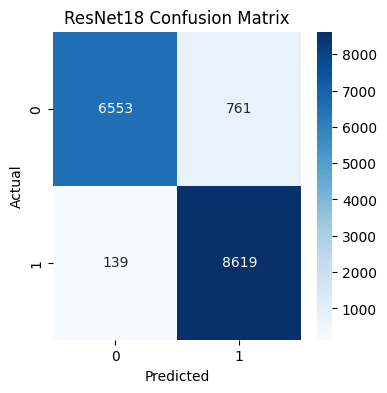

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      7314
           1       0.92      0.98      0.95      8758

    accuracy                           0.94     16072
   macro avg       0.95      0.94      0.94     16072
weighted avg       0.95      0.94      0.94     16072


Evaluating ResNet50


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\1785831814.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


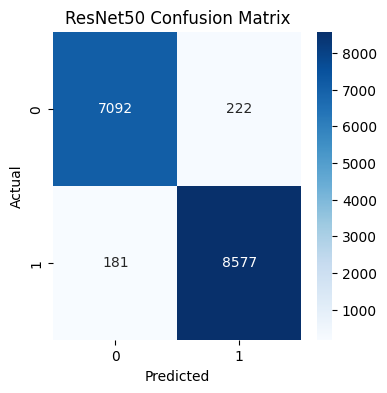

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      7314
           1       0.97      0.98      0.98      8758

    accuracy                           0.97     16072
   macro avg       0.97      0.97      0.97     16072
weighted avg       0.97      0.97      0.97     16072


Evaluating DenseNet121


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\1785831814.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


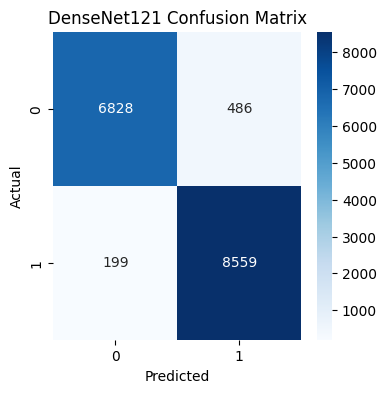

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7314
           1       0.95      0.98      0.96      8758

    accuracy                           0.96     16072
   macro avg       0.96      0.96      0.96     16072
weighted avg       0.96      0.96      0.96     16072


Evaluating EfficientNet


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\1785831814.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


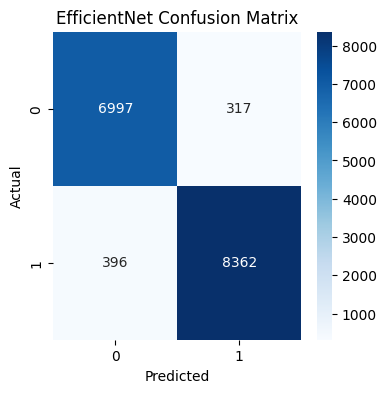

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7314
           1       0.96      0.95      0.96      8758

    accuracy                           0.96     16072
   macro avg       0.95      0.96      0.96     16072
weighted avg       0.96      0.96      0.96     16072


Evaluating ConvNeXt


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_20728\1785831814.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


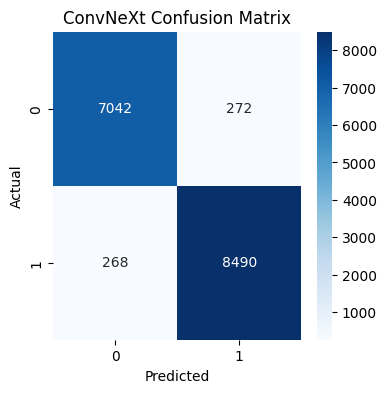

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7314
           1       0.97      0.97      0.97      8758

    accuracy                           0.97     16072
   macro avg       0.97      0.97      0.97     16072
weighted avg       0.97      0.97      0.97     16072


FINAL MODEL COMPARISON

          Model  Accuracy     APCER     BPCER      HTER
0      ResNet18  0.944002  0.104047  0.015871  0.059959
1      ResNet50  0.974925  0.030353  0.020667  0.025510
2   DenseNet121  0.957379  0.066448  0.022722  0.044585
3  EfficientNet  0.955637  0.043342  0.045216  0.044279
4      ConvNeXt  0.966401  0.037189  0.030601  0.033895


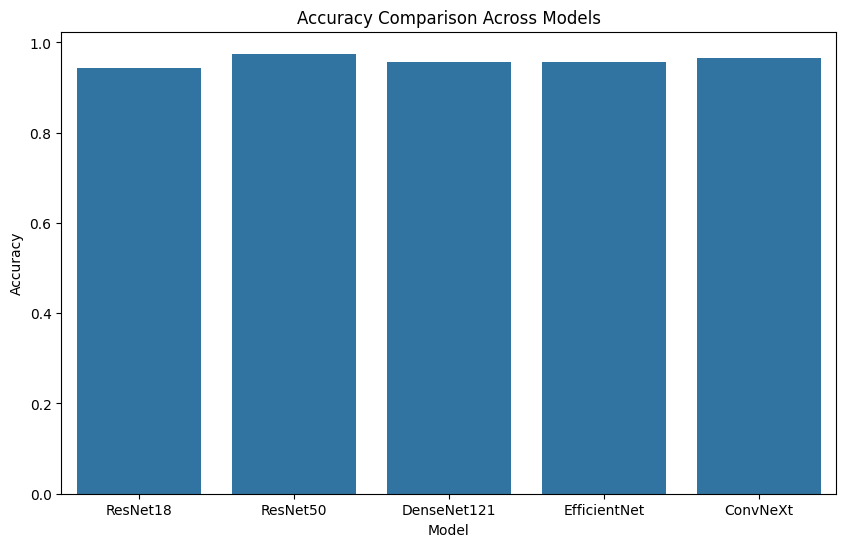

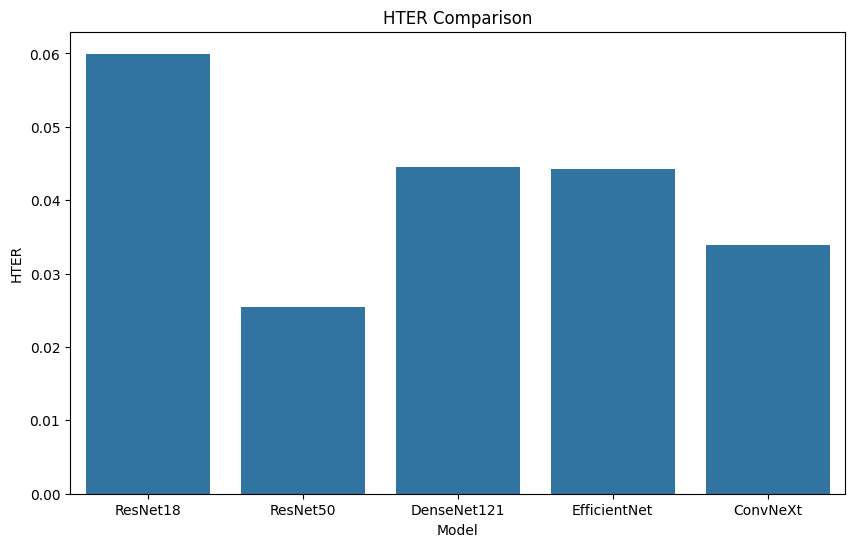

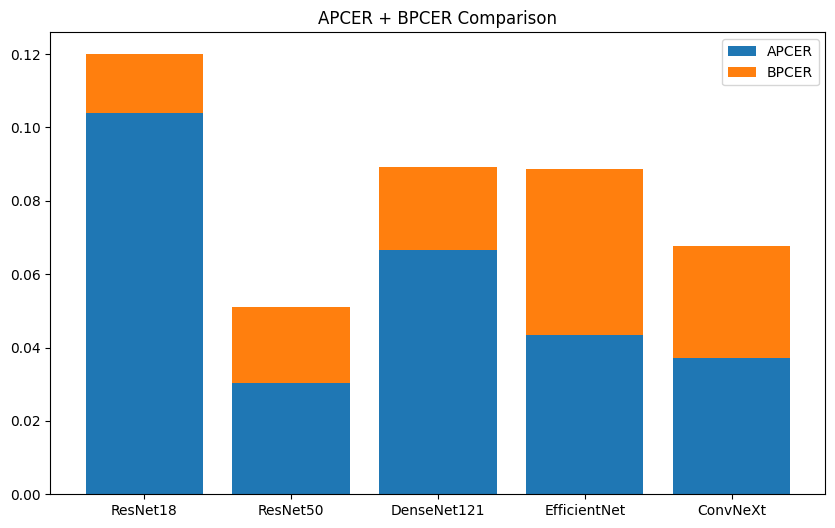

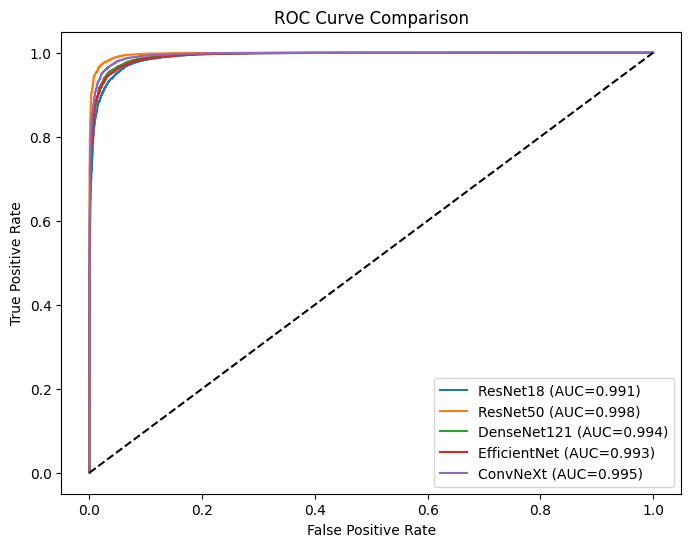

In [35]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from torchvision.models import (
    resnet18,resnet50,densenet121,
    efficientnet_b0,convnext_tiny,
    ResNet18_Weights,ResNet50_Weights,
    DenseNet121_Weights,EfficientNet_B0_Weights,
    ConvNeXt_Tiny_Weights
)

# ==========================
# MODEL LOADER
# ==========================

def load_model(name,path):

    if name=="ResNet18":
        model=resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc=nn.Linear(model.fc.in_features,2)

    elif name=="ResNet50":
        model=resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc=nn.Linear(model.fc.in_features,2)

    elif name=="DenseNet121":
        model=densenet121(weights=DenseNet121_Weights.DEFAULT)
        model.classifier=nn.Linear(model.classifier.in_features,2)

    elif name=="EfficientNet":
        model=efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1]=nn.Linear(model.classifier[1].in_features,2)

    elif name=="ConvNeXt":
        model=convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2]=nn.Linear(model.classifier[2].in_features,2)

    model.load_state_dict(torch.load(path))
    model=model.to(DEVICE)
    model.eval()

    return model


# ==========================
# MODEL FILES
# ==========================

models_dict={
"ResNet18":"resnet18_pad_final.pth",
"ResNet50":"resnet50_best_model.pth",
"DenseNet121":"densenet_best_model.pth",
"EfficientNet":"efficientnet_best_model.pth",
"ConvNeXt":"convnext_best_model.pth"
}

results=[]
roc_data={}

# ==========================
# EVALUATION LOOP
# ==========================

for model_name,path in models_dict.items():

    print("\nEvaluating",model_name)

    model=load_model(model_name,path)

    all_preds=[]
    all_labels=[]
    all_probs=[]

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(DEVICE)

            outputs=model(images)

            probs=torch.softmax(outputs,dim=1)[:,1].cpu().numpy()

            preds=torch.argmax(outputs,1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm=confusion_matrix(all_labels,all_preds)

    TN,FP,FN,TP=cm.ravel()

    accuracy=(TP+TN)/(TP+TN+FP+FN)

    APCER=FP/(FP+TN)
    BPCER=FN/(FN+TP)
    HTER=(APCER+BPCER)/2

    results.append({
        "Model":model_name,
        "Accuracy":accuracy,
        "APCER":APCER,
        "BPCER":BPCER,
        "HTER":HTER
    })

    # ROC
    fpr,tpr,_=roc_curve(all_labels,all_probs)
    roc_auc=auc(fpr,tpr)

    roc_data[model_name]=(fpr,tpr,roc_auc)

    # Confusion Matrix
    plt.figure(figsize=(4,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(model_name+" Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(all_labels,all_preds))


# ==========================
# RESULTS TABLE
# ==========================

df=pd.DataFrame(results)

print("\nFINAL MODEL COMPARISON\n")
print(df)


# ==========================
# ACCURACY COMPARISON
# ==========================

plt.figure(figsize=(10,6))
sns.barplot(x="Model",y="Accuracy",data=df)
plt.title("Accuracy Comparison Across Models")
plt.show()


# ==========================
# HTER COMPARISON
# ==========================

plt.figure(figsize=(10,6))
sns.barplot(x="Model",y="HTER",data=df)
plt.title("HTER Comparison")
plt.show()


# ==========================
# APCER / BPCER
# ==========================

plt.figure(figsize=(10,6))

x=np.arange(len(df["Model"]))

plt.bar(x,df["APCER"],label="APCER")
plt.bar(x,df["BPCER"],bottom=df["APCER"],label="BPCER")

plt.xticks(x,df["Model"])
plt.legend()

plt.title("APCER + BPCER Comparison")
plt.show()


# ==========================
# ROC CURVES (RESEARCH PAPERS)
# ==========================

plt.figure(figsize=(8,6))

for model_name,(fpr,tpr,roc_auc) in roc_data.items():

    plt.plot(fpr,tpr,label=f"{model_name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


# ==========================
# OPTIONAL TRAIN/VAL CURVE TEMPLATE
# ==========================

# If you logged training metrics you can plot them like this

# Example placeholder
# epochs = range(1,13)
# train_loss = [...]
# val_loss = [...]

# plt.plot(epochs,train_loss,label="Train Loss")
# plt.plot(epochs,val_loss,label="Validation Loss")
# plt.legend()
# plt.title("Training vs Validation Loss")
# plt.show()



In [36]:
df.to_csv("model_comparison_results.csv", index=False)



In [37]:
torch.save(model.state_dict(), "final_pad_model_resnet50.pth")



In [38]:
pip install streamlit opencv-python pillow torchvision

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.1 MB 7.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.1 MB 6.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.2/9.1 MB 7.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/9.1 MB 7.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/9.1 MB 6.9 MB/s eta 0:00:01
   -------------------------------- ------- 7.3/9.1 MB 6.1 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.9 MB/s  0:00:01
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 11.3 MB/s  0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.0 MB 8.5 MB/s eta 0:00:02
   ------ --------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.3 which is incompatible.
facenet-pytorch 2.6.0 requires torch<2.3.0,>=2.2.0, but you have torch 2.5.1+cu121 which is incompatible.
facenet-pytorch 2.6.0 requires torchvision<0.18.0,>=0.17.0, but you have torchvision 0.20.1+cu121 which is incompatible.


In [37]:
from torchvision import datasets

dataset = datasets.ImageFolder(r"D:\College\Major project\Dataset\finetune_data")

print(dataset.class_to_idx)
print(len(dataset))

{'real': 0, 'spoof': 1}
325


In [38]:
DATA_DIR = r"D:\College\Major project\finetune_data"

In [40]:
# =========================================
# 1. IMPORTS
# =========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import copy
import os

# =========================================
# 2. CONFIG
# =========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = r"D:\College\Major project\Dataset\finetune_data"
MODEL_PATH = r"D:\majorML\pad_demo\final_pad_model_resnet50.pth"
SAVE_PATH = r"D:\majorML\pad_demo\finetuned_model.pth"

BATCH_SIZE = 16
EPOCHS = 15
LR = 5e-5

# =========================================
# 3. VERIFY DATASET
# =========================================
print("Checking dataset...")
print(os.listdir(DATA_DIR))

dataset = datasets.ImageFolder(DATA_DIR)
print("Class mapping:", dataset.class_to_idx)

assert dataset.class_to_idx == {'real': 0, 'spoof': 1}, \
    "❌ Fix folder names: must be 'real' and 'spoof'"

# =========================================
# 4. TRANSFORMS
# =========================================
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# =========================================
# 5. SPLIT DATA
# =========================================
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))

train_ds.dataset.transform = train_tf
val_ds.dataset.transform = val_tf

# =========================================
# 6. BALANCED SAMPLER
# =========================================
labels = dataset.targets
n_real = labels.count(0)
n_spoof = labels.count(1)

print(f"Real: {n_real}, Spoof: {n_spoof}")

class_weights = [1.0/n_real, 1.0/n_spoof]

train_labels = [dataset.targets[i] for i in train_ds.indices]
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# =========================================
# 7. LOAD MODEL
# =========================================
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Freeze everything except last layers
for name, param in model.named_parameters():
    param.requires_grad = any(k in name for k in ["layer4", "fc"])

model = model.to(DEVICE)

# =========================================
# 8. LOSS + OPTIMIZER
# =========================================
weights = torch.tensor([1.0/n_real, 1.0/n_spoof]).to(DEVICE)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# =========================================
# 9. TRAINING LOOP
# =========================================
best_loss = float("inf")
patience = 5
counter = 0
best_weights = None

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    acc = 100 * correct / total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {acc:.2f}%")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_PATH)
        counter = 0
        print("✅ Saved best model")
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping triggered")
            break

# =========================================
# 10. FINISH
# =========================================
model.load_state_dict(best_weights)
print("🎯 Fine-tuning complete!")
print(f"Model saved at: {SAVE_PATH}")# =========================================


Checking dataset...
['real', 'spoof']
Class mapping: {'real': 0, 'spoof': 1}
Real: 150, Spoof: 175


C:\Users\Sanjeev's LOQ\AppData\Local\Temp\ipykernel_9000\2252599855.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_loc


Epoch 1/15
Train Loss: 1.1885
Val Loss: 0.6363, Acc: 87.69%
✅ Saved best model

Epoch 2/15
Train Loss: 0.4447
Val Loss: 0.1179, Acc: 96.92%
✅ Saved best model

Epoch 3/15
Train Loss: 0.1054
Val Loss: 0.0460, Acc: 98.46%
✅ Saved best model

Epoch 4/15
Train Loss: 0.0505
Val Loss: 0.0363, Acc: 98.46%
✅ Saved best model

Epoch 5/15
Train Loss: 0.0494
Val Loss: 0.0185, Acc: 100.00%
✅ Saved best model

Epoch 6/15
Train Loss: 0.0253
Val Loss: 0.0057, Acc: 100.00%
✅ Saved best model

Epoch 7/15
Train Loss: 0.0093
Val Loss: 0.0045, Acc: 100.00%
✅ Saved best model

Epoch 8/15
Train Loss: 0.0137
Val Loss: 0.0066, Acc: 100.00%

Epoch 9/15
Train Loss: 0.0042
Val Loss: 0.0017, Acc: 100.00%
✅ Saved best model

Epoch 10/15
Train Loss: 0.0047
Val Loss: 0.0015, Acc: 100.00%
✅ Saved best model

Epoch 11/15
Train Loss: 0.0029
Val Loss: 0.0013, Acc: 100.00%
✅ Saved best model

Epoch 12/15
Train Loss: 0.0047
Val Loss: 0.0010, Acc: 100.00%
✅ Saved best model

Epoch 13/15
Train Loss: 0.0022
Val Loss: 0.0009

In [41]:
MODEL_PATH = r"D:\majorML\pad_demo\finetuned_model.pth"